In [1]:
import utility as ut
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
DIRECTORY = "data/"
datasets = ut.load_excel_data(DIRECTORY)

In [ ]:
DURATION = 15  # duration in seconds
DT = 0.0001  # time increment in seconds    // Actual DT is irregular
# Create a time array
time_array = np.arange(0, DURATION + DT, DT)
NUM_STEPS = len(time_array)

In [4]:
interpolated_datasets = []
for i in range(len(datasets)):
    new_trolley_position = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["trolley_position"]
    )
    new_cable_length = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["cable_length"]
    )
    new_sway_angle = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["sway_angle"]
    )
    new_trolley_speed = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["trolley_position_first_derivative"]
    )
    new_cable_speed = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["cable_length_first_derivative"]
    )
    new_trolley_motor_pwm = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["pwm_trolley_motor"]
    )
    new_hoist_motor_pwm = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["pwm_hoist_motor"]
    )
    new_trolley_motor_voltage = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["trolley_motor_voltage"]
    )
    new_hoist_motor_voltage = np.interp(
        time_array, datasets[i]["timestamp"], datasets[i]["hoist_motor_voltage"]
    )

    interpolated_df = {
        "time": time_array,
        "trolley_position": new_trolley_position,
        "cable_length": new_cable_length,
        "sway_angle": new_sway_angle,
        "trolley_speed": new_trolley_speed,
        "cable_speed": new_cable_speed,
        "trolley_motor_pwm": new_trolley_motor_pwm,
        "hoist_motor_pwm": new_hoist_motor_pwm,
        "trolley_motor_voltage": new_trolley_motor_voltage,
        "hoist_motor_voltage": new_hoist_motor_voltage,
    }

    interpolated_datasets.append(interpolated_df)

print(len(interpolated_datasets))


39


In [5]:
max_sway_angle = 0
for i in range(len(interpolated_datasets)):
    max_sway_angle = max(
        max_sway_angle, max(abs(interpolated_datasets[i]["sway_angle"]))
    )
max_sway_angle *= 1.1

max_sway_angle = np.rad2deg(max_sway_angle)

# Sort the interpolated_datasets by average trolley motor PWM from lowest to highest and then by average hoist motor PWM from lowest to highest
interpolated_datasets.sort(key=lambda x: np.mean(x["trolley_motor_pwm"]))
interpolated_datasets.sort(key=lambda x: np.mean(x["hoist_motor_pwm"]))

for key in interpolated_datasets[0]:
    print(key)

time
trolley_position
cable_length
sway_angle
trolley_speed
cable_speed
trolley_motor_pwm
hoist_motor_pwm
trolley_motor_voltage
hoist_motor_voltage


In [6]:
USE_BEST_DATASET = True
best_dataset = []
if USE_BEST_DATASET:
    for index in range(len(interpolated_datasets)):
        if (index >= 9 and index <= 20) or (index >= 30):
            continue
        best_dataset.append(interpolated_datasets[index])
    
    interpolated_datasets = best_dataset
print(len(interpolated_datasets))

# Sort the interpolated_datasets by average trolley motor PWM from lowest to highest and then by average hoist motor PWM from lowest to highest
interpolated_datasets.sort(key=lambda x: np.mean(x["trolley_motor_pwm"]))
interpolated_datasets.sort(key=lambda x: np.mean(x["hoist_motor_pwm"]))

18


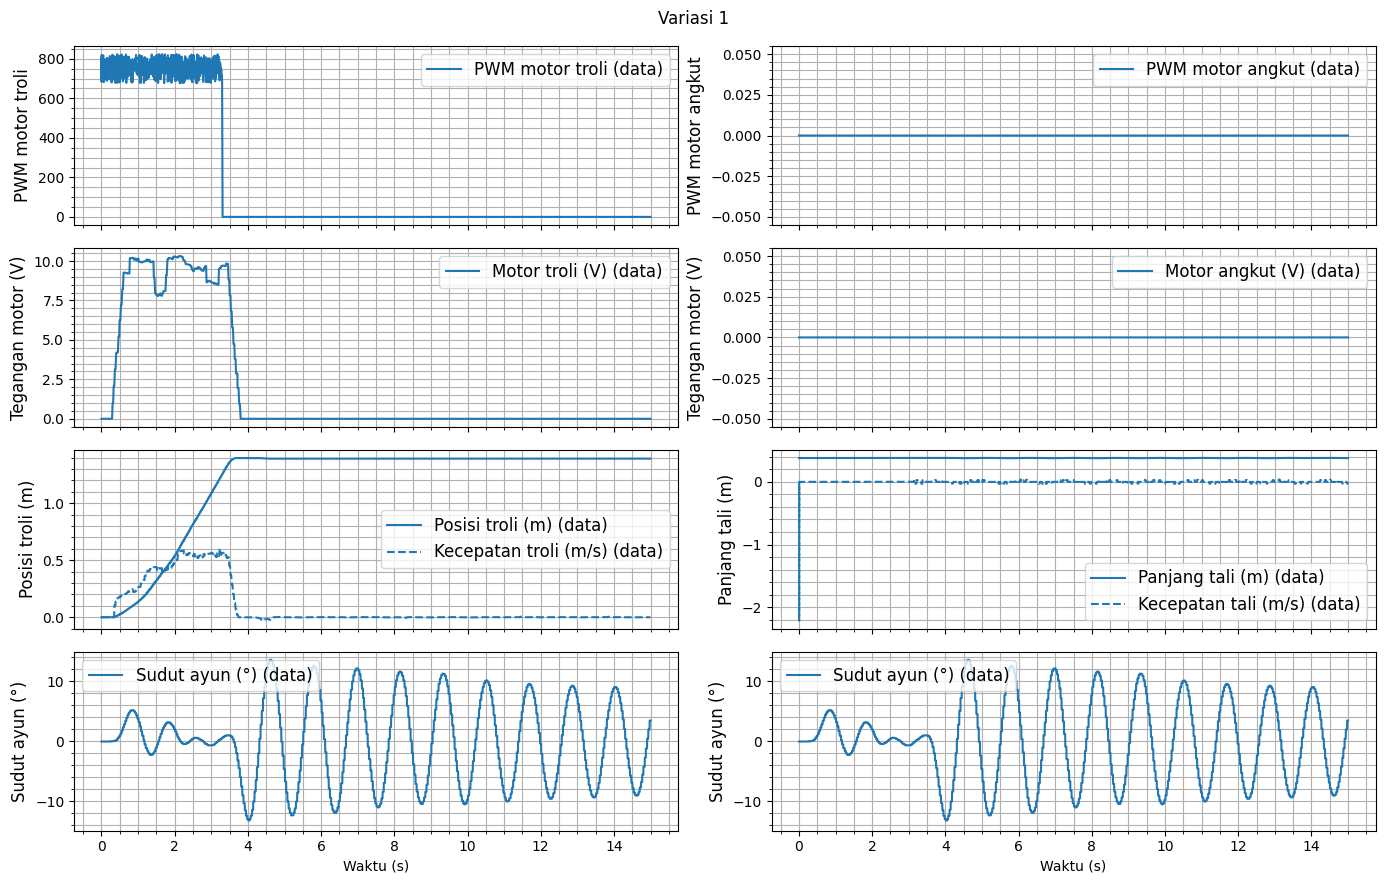

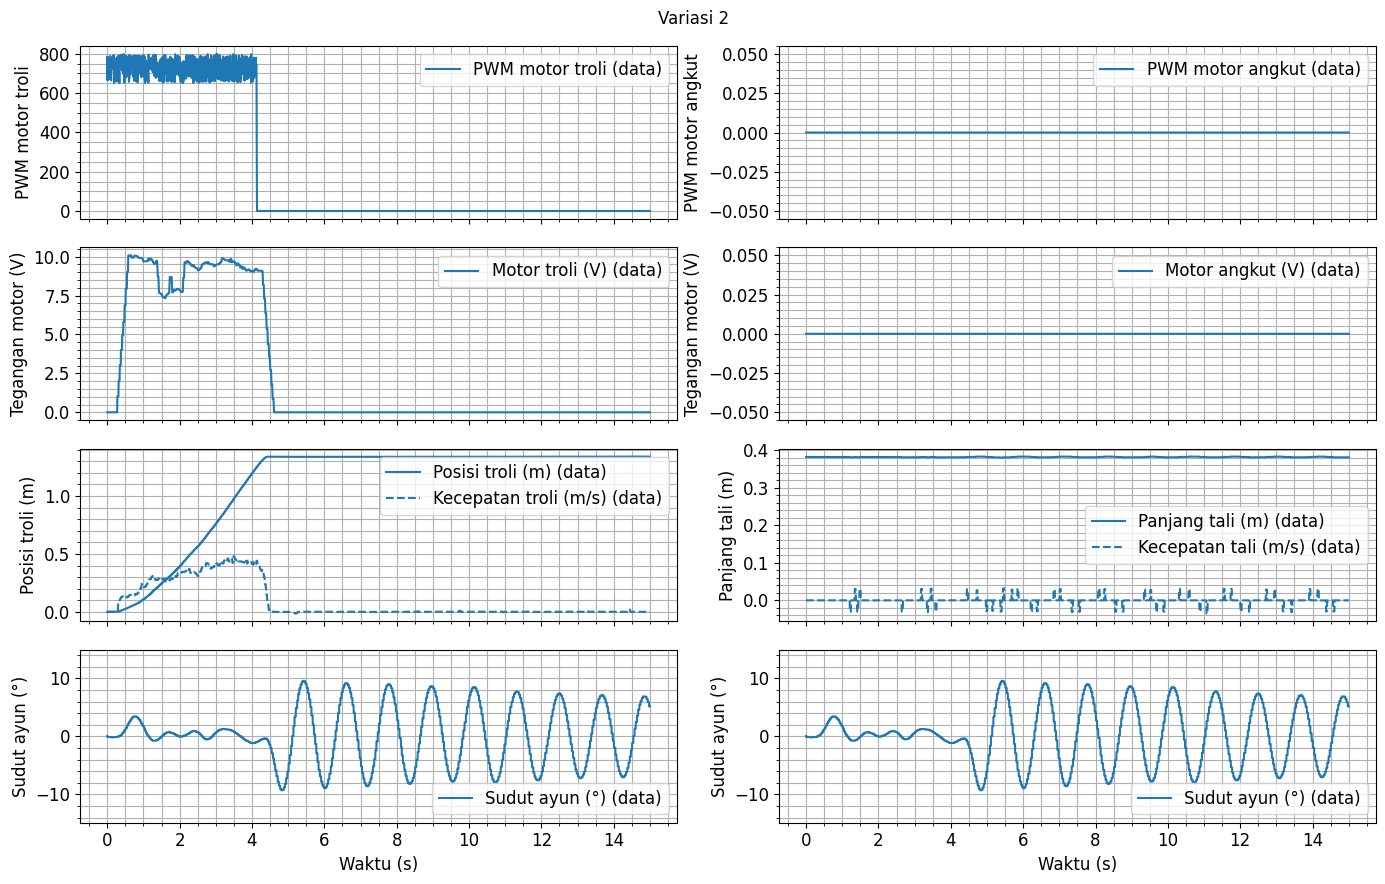

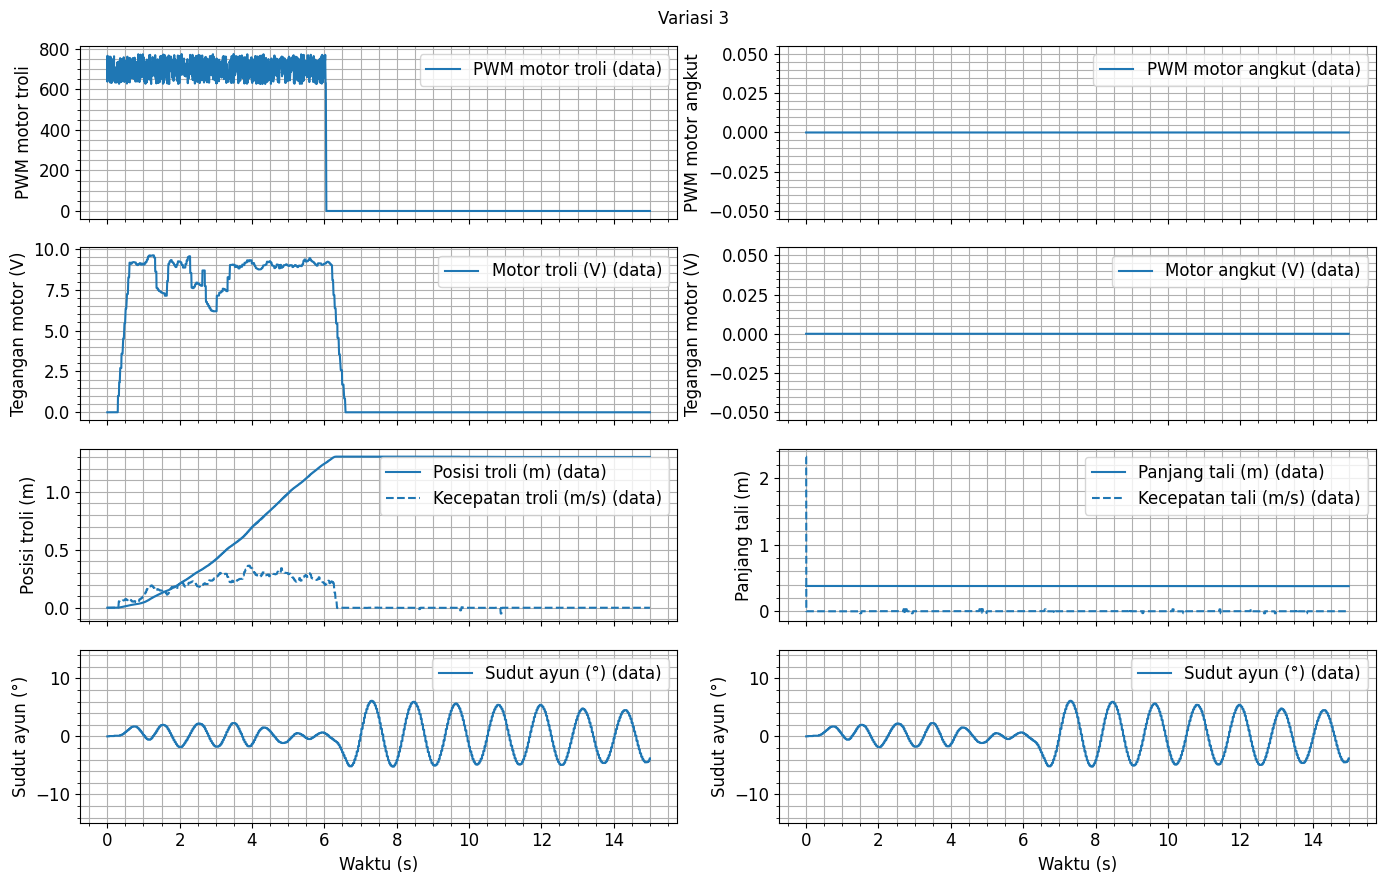

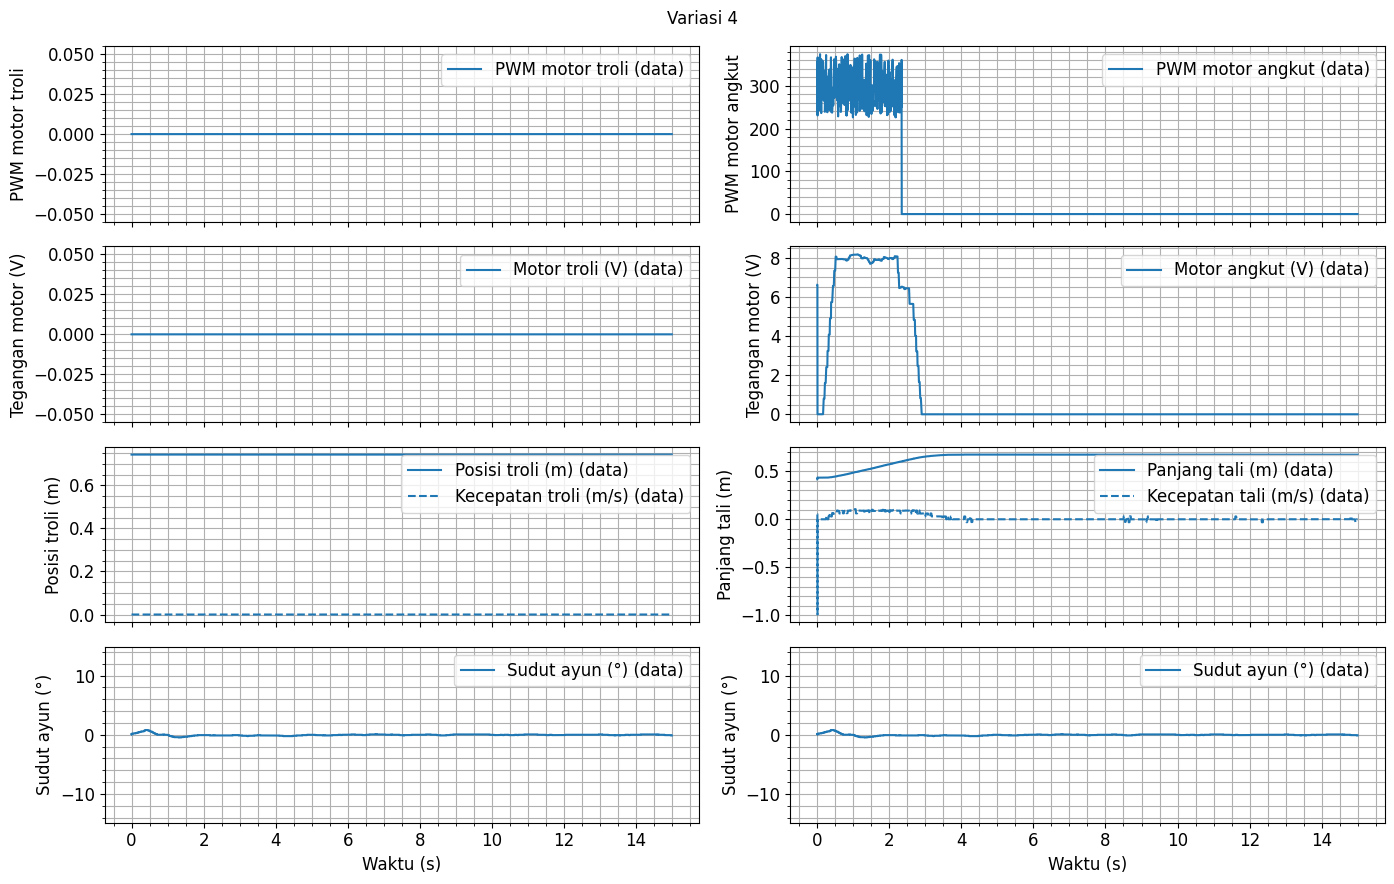

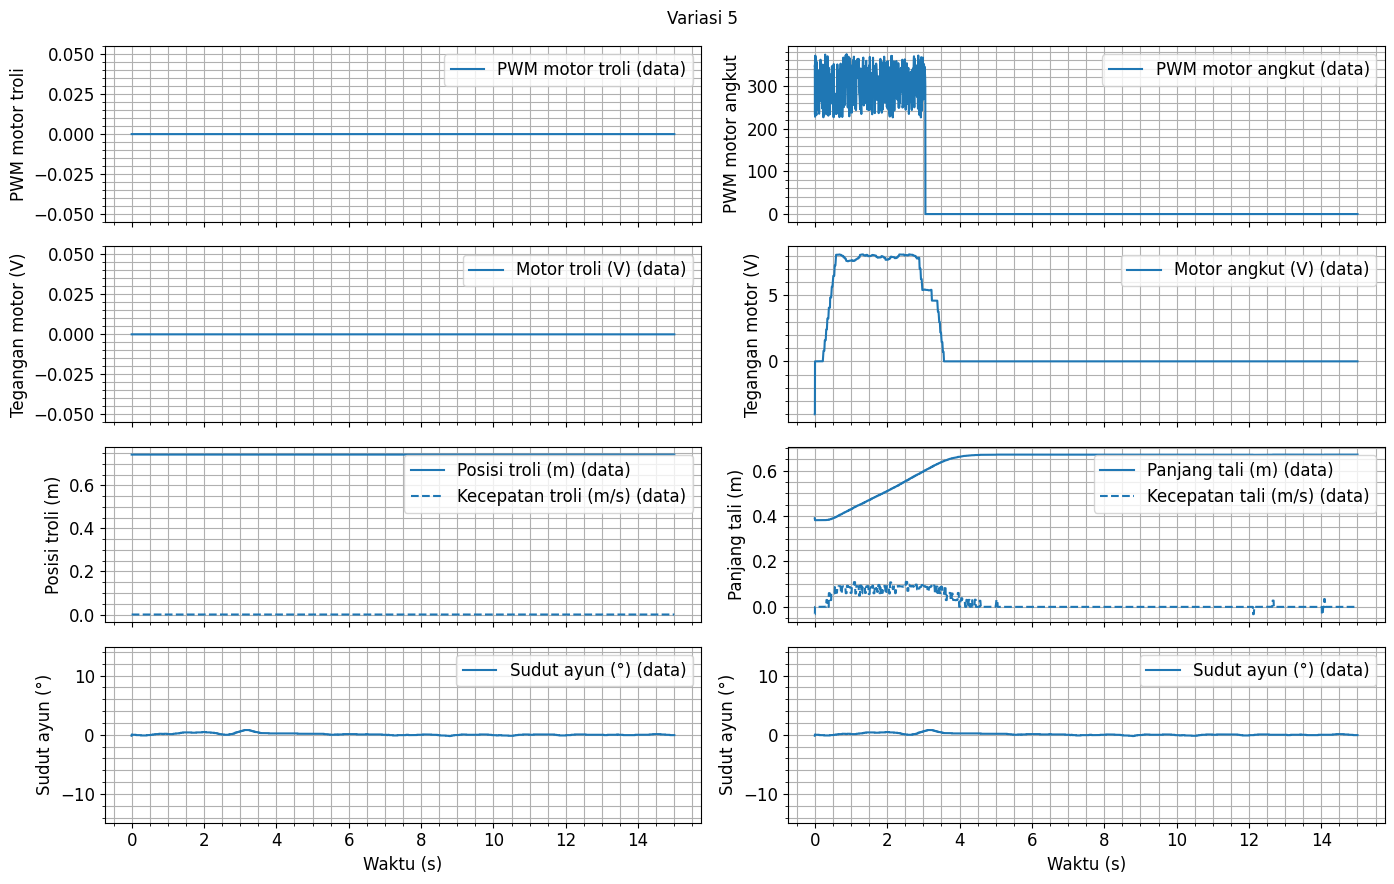

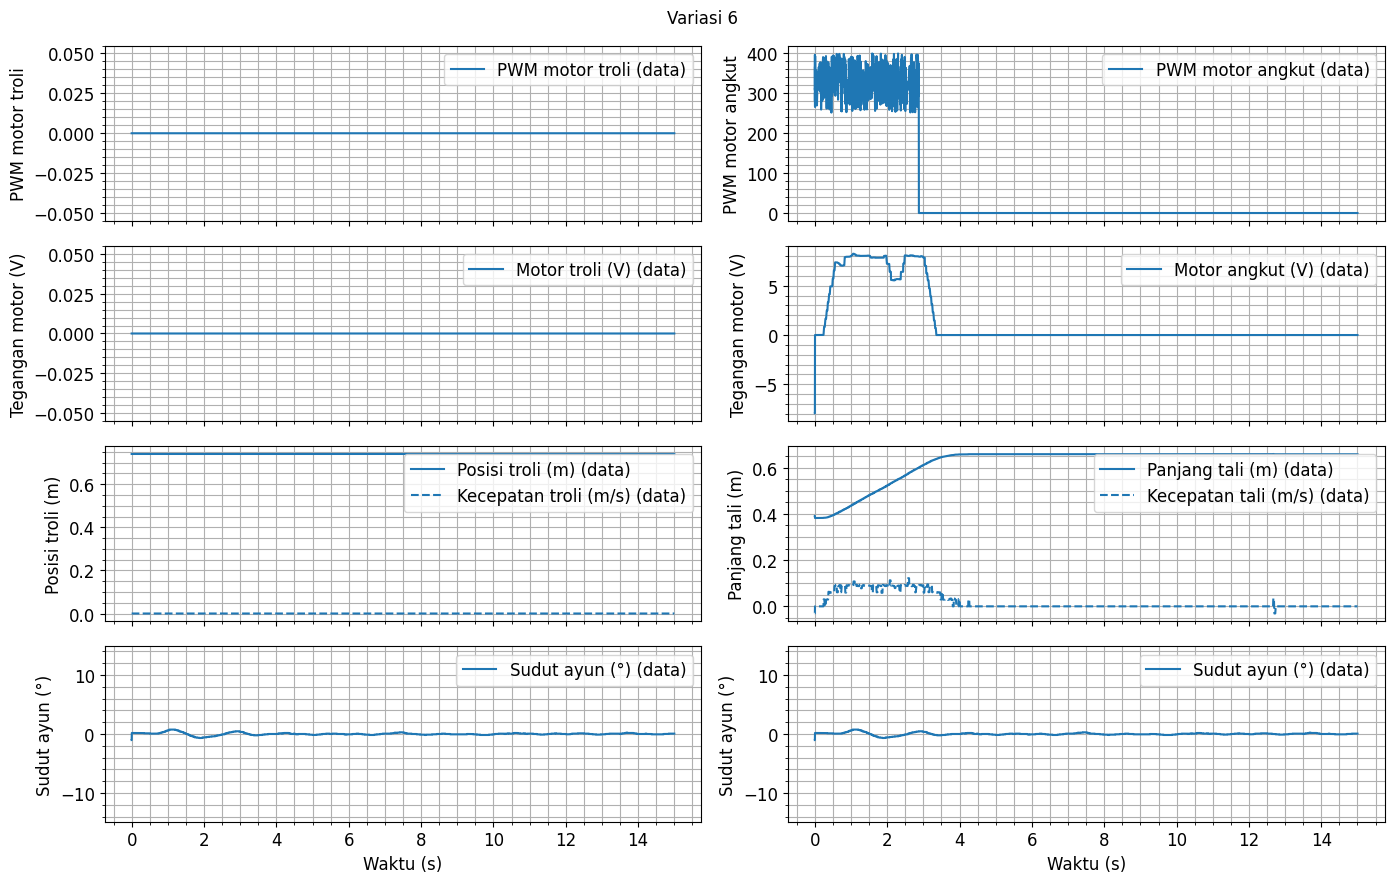

In [7]:
# Plot the interpolated datasets
j = 0
for index, dataset in enumerate(interpolated_datasets):
    if index % 3 != 0:
        continue
    # Create a figure and a set of subplots
    figure, ax = plt.subplots(4, 2, figsize=(14, 9), sharex=True)
    title = "Variasi " + str(j + 1)
    plt.rcParams.update({"font.size": 12})
    figure.suptitle(title, fontsize=12)
    ut.add_to_subplot(ax[0, 0], dataset["time"], dataset["trolley_motor_pwm"], ylabel="PWM motor troli (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[0, 1], dataset["time"], dataset["hoist_motor_pwm"], ylabel="PWM motor angkut (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[1, 0], dataset["time"], dataset["trolley_motor_voltage"], ylabel="Motor troli (V) (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[1, 1], dataset["time"], dataset["hoist_motor_voltage"], ylabel="Motor angkut (V) (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[2, 0], dataset["time"], dataset["trolley_position"], ylabel="Posisi troli (m) (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[2, 0], dataset["time"], dataset["trolley_speed"], ylabel="Kecepatan troli (m/s) (data)", color=plt.get_cmap("tab20")(0), linestyle="--")
    ut.add_to_subplot(ax[2, 1], dataset["time"], dataset["cable_length"], ylabel="Panjang tali (m) (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[2, 1], dataset["time"], dataset["cable_speed"], ylabel="Kecepatan tali (m/s) (data)", color=plt.get_cmap("tab20")(0), linestyle="--")
    ut.add_to_subplot(ax[3, 0], dataset["time"], np.rad2deg(dataset["sway_angle"]), "Waktu (s)", "Sudut ayun (°) (data)", color=plt.get_cmap("tab20")(0))
    ut.add_to_subplot(ax[3, 1], dataset["time"], np.rad2deg(dataset["sway_angle"]), "Waktu (s)", "Sudut ayun (°) (data)", color=plt.get_cmap("tab20")(0))
    ax[3, 0].set_ylim(-max_sway_angle, max_sway_angle)
    ax[3, 1].set_ylim(-max_sway_angle, max_sway_angle)
    ax[2, 0].grid(which="both")
    ax[2, 1].grid(which="both")

    ax[0, 0].set_ylabel("PWM motor troli", fontsize=12)
    ax[0, 1].set_ylabel("PWM motor angkut", fontsize=12)
    ax[1, 0].set_ylabel("Tegangan motor (V)", fontsize=12)
    ax[1, 1].set_ylabel("Tegangan motor (V)", fontsize=12)
    ax[2, 0].set_ylabel("Posisi troli (m)", fontsize=12)
    ax[2, 1].set_ylabel("Panjang tali (m)", fontsize=12)
    ax[3, 0].set_ylabel("Sudut ayun (°)", fontsize=12)
    ax[3, 1].set_ylabel("Sudut ayun (°)", fontsize=12)

    plt.tight_layout()

    # Save the figure as SVG
    plt.savefig(DIRECTORY + "figure/"+ title +".svg")
    plt.show()
    j += 1